DATA SOURCE: https://apps.fs.usda.gov/fia/datamart/datamart.html

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

# for Vermont State (VT)
df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/VT_TREE.csv')

In [37]:
print(df.groupby('DIAHTCD').size()) # how was measured
print(df.groupby('STATUSCD').size()) # died, live, broken
print(df.groupby('HTCD').size())   # metode of measurement

DIAHTCD
1    204041
dtype: int64
STATUSCD
0      8827
1    167309
2     26712
3      1193
dtype: int64
HTCD
1.0    76043
2.0     5442
3.0    26310
4.0    21234
dtype: int64


In [38]:
df = df[df.ACTUALHT == df.HT] 
df = df[['INVYR', 'UNITCD', 'COUNTYCD', 'PLOT', 'TREE', 'DIA', 'HT', 'SPCD']]
red_spruce = df[df.SPCD == 97] # code for red spruce

In [39]:
red_spruce = red_spruce.rename(columns = {
'INVYR': 'inventory_year', 'UNITCD': 'survey_unit',
'COUNTYCD': 'country', 'PLOT': 'plot_number',
'TREE': 'tree_number', 'DIA': 'diametr', 'HT': 'height'})

In [40]:
red_spruce.dtypes

inventory_year      int64
survey_unit         int64
country             int64
plot_number         int64
tree_number         int64
diametr           float64
height            float64
SPCD              float64
dtype: object

In [41]:
red_spruce.info()

<class 'pandas.DataFrame'>
Index: 6877 entries, 59152 to 204025
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventory_year  6877 non-null   int64  
 1   survey_unit     6877 non-null   int64  
 2   country         6877 non-null   int64  
 3   plot_number     6877 non-null   int64  
 4   tree_number     6877 non-null   int64  
 5   diametr         6877 non-null   float64
 6   height          6877 non-null   float64
 7   SPCD            6877 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 483.5 KB


In [42]:
red_spruce.describe()

,inventory_year,survey_unit,country,plot_number,tree_number,diametr,height,SPCD
count,6877.000000,6877.000000,6877.000000,6877.000000,6877.000000,6877.000000,6877.000000,6877.0
mean,2013.959139,2.543842,14.898211,1024.661917,12.563036,7.961189,43.297513,97.0
std,6.324826,0.498110,9.134703,808.940716,10.138869,3.805466,17.610745,0.0
min,2003.000000,2.000000,1.000000,12.000000,1.000000,1.000000,6.000000,97.0
25%,2008.000000,2.000000,5.000000,407.000000,5.000000,5.600000,32.000000,97.0
50%,2014.000000,3.000000,17.000000,883.000000,10.000000,7.300000,43.000000,97.0
75%,2020.000000,3.000000,23.000000,1303.000000,17.000000,10.100000,56.000000,97.0
max,2024.000000,3.000000,27.000000,3515.000000,73.000000,26.600000,99.000000,97.0


In [43]:
red_spruce.duplicated().sum()

np.int64(0)

In [44]:
YEAR = 2022
red_spruce_per_year = red_spruce[red_spruce.inventory_year == YEAR]

In [45]:
grouped_by_trees = red_spruce_per_year.groupby(['survey_unit', 'country', 
                                       'plot_number', 'tree_number'])

actual_measurement = red_spruce_per_year.loc[grouped_by_trees.inventory_year.idxmax()]

In [46]:
actual_measurement['height'] = actual_measurement['height']*0.3048 # feet to meters
actual_measurement['diametr'] = actual_measurement['diametr']*2.54 # inches to centemetrs

In [47]:
actual_measurement['log_height'] = np.log(actual_measurement.height)
actual_measurement['log_diametr'] = np.log(actual_measurement.diametr)
actual_measurement.head()

,inventory_year,survey_unit,country,plot_number,tree_number,diametr,height,SPCD,log_height,log_diametr
185487,2022,2,5,204,1,18.796,11.5824,97.0,2.449487,2.933644
185513,2022,2,5,204,3,19.050,12.1920,97.0,2.500780,2.947067
185489,2022,2,5,204,4,28.702,12.8016,97.0,2.549570,3.356967
185471,2022,2,5,204,5,32.258,18.2880,97.0,2.906245,3.473766
185473,2022,2,5,204,7,30.226,18.5928,97.0,2.922774,3.408702


<Axes: xlabel='diametr', ylabel='height'>

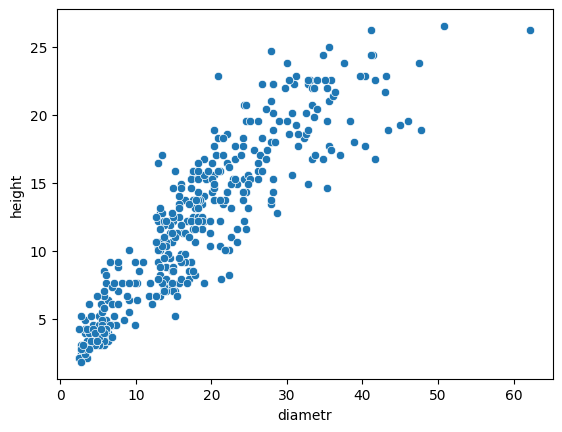

In [51]:
sns.scatterplot(x = 'diametr', y = 'height', data = actual_measurement)

<Axes: xlabel='log_diametr', ylabel='log_height'>

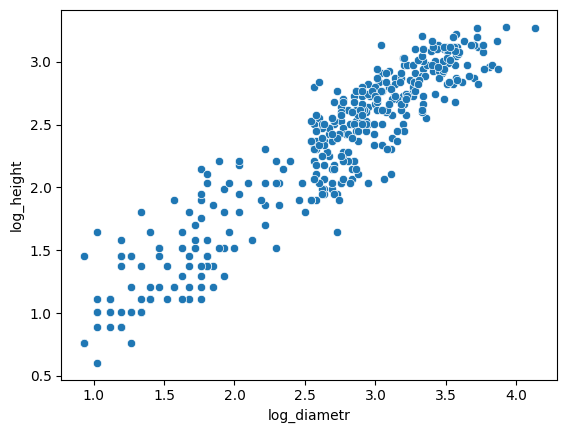

In [50]:
sns.scatterplot(x = 'log_diametr', y = 'log_height', data = actual_measurement)

In [52]:
actual_measurement.to_csv('red_spruce_2022.csv', index=False, encoding='utf-8-sig')